# Laboratorio de Control Térmico: Diseño de PID

In [379]:
import tclab
import control as cs
import matplotlib.pyplot as plt

Vamos a realizar como primer paso la simulación de nuestro sistema termico sin tiempo muerto, de modo que podamos observar un comportamiento base a nuestra planta realizada.

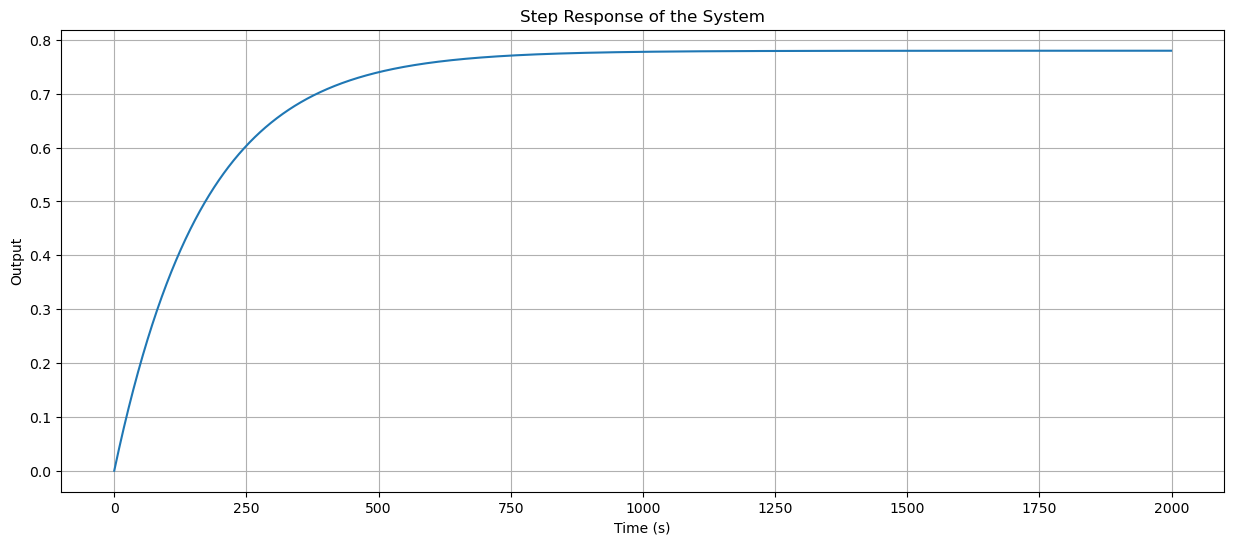

In [380]:
# Instance of our transfer function
k = 0.78
tau = 168.2
theta = 20.01

# Making no-dead time transfer function
G = cs.TransferFunction([k], [tau, 1])

# Time vector
t = range(0, 2000) # 0 to 2000 seconds

# Step response
t, y = cs.step_response(G, t)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(t, y)
plt.title('Step Response of the System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()


Para ahora nuevamente ver nuestra respuesta con respecto a una retroalimentación y variando nuestra ganancia K.

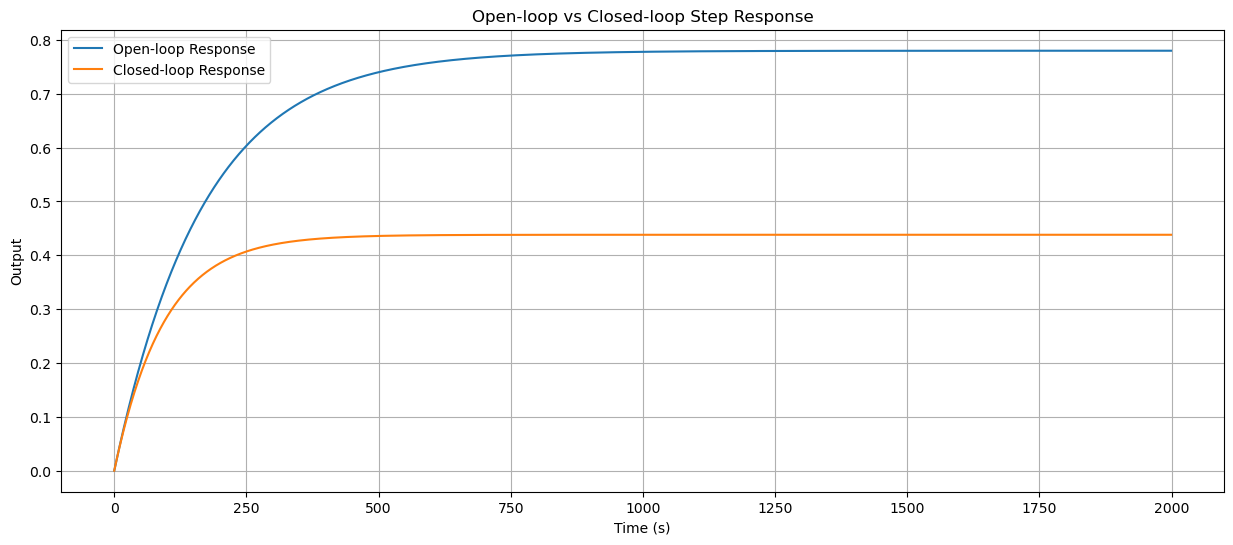

In [381]:
# Define new transfer function
Gs = cs.TransferFunction([k], [tau, 1])

# Define controller for Gs
Controller = cs.TransferFunction([1], [1])  # Proportional controller with gain 1

# Closed-loop transfer function
Closed_Loop = cs.feedback(Controller * Gs, 1)

# Step response of closed-loop system
t_cl, y_cl = cs.step_response(Closed_Loop, t)

# Plotting closed-loop response & open-loop response
plt.figure(figsize=(15, 6))
plt.plot(t, y, label='Open-loop Response')
plt.plot(t_cl, y_cl, label='Closed-loop Response')
plt.title('Open-loop vs Closed-loop Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()
plt.grid()

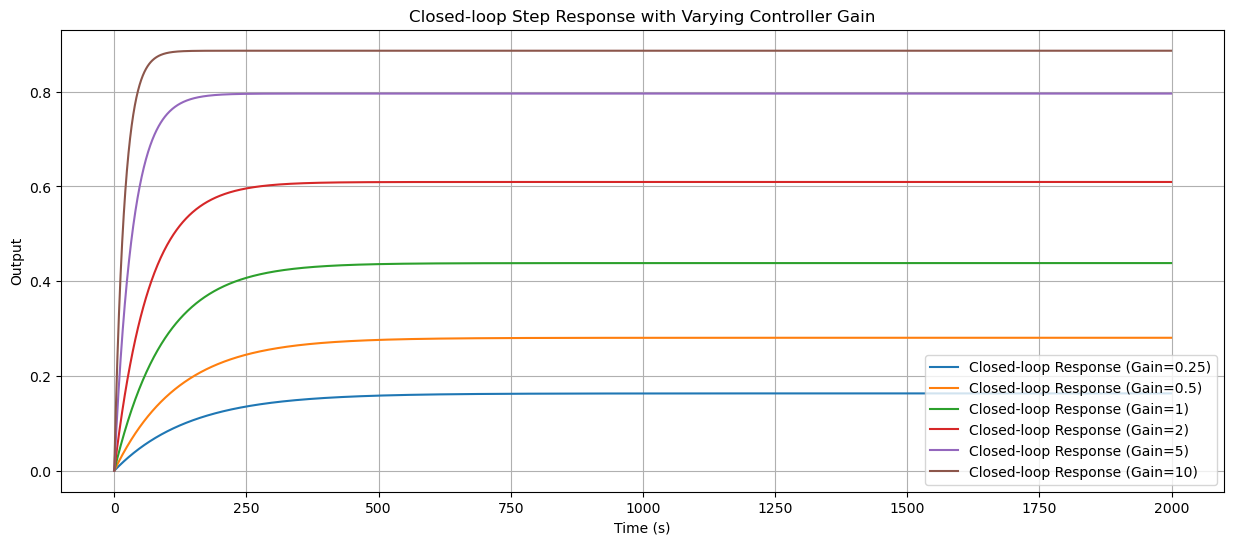

In [382]:
# New plot for the closed-loop response varying its controller value gain
plt.figure(figsize=(15, 6))

for i in [0.25, 0.5, 1, 2, 5, 10]:  # Different controller gains
    Controller = cs.TransferFunction([i], [1])  # Proportional controller with varying gain
    Closed_Loop = cs.feedback(Controller * Gs, 1)  # Closed-loop transfer function
    t_cl, y_cl = cs.step_response(Closed_Loop, t)  # Step response of closed-loop system
    plt.plot(t_cl, y_cl, label=f'Closed-loop Response (Gain={i})')

plt.title('Closed-loop Step Response with Varying Controller Gain')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Realizamos la simulación con tiempo muerto de lo previamente definido para observar oscilaciones en nuestro sistema.

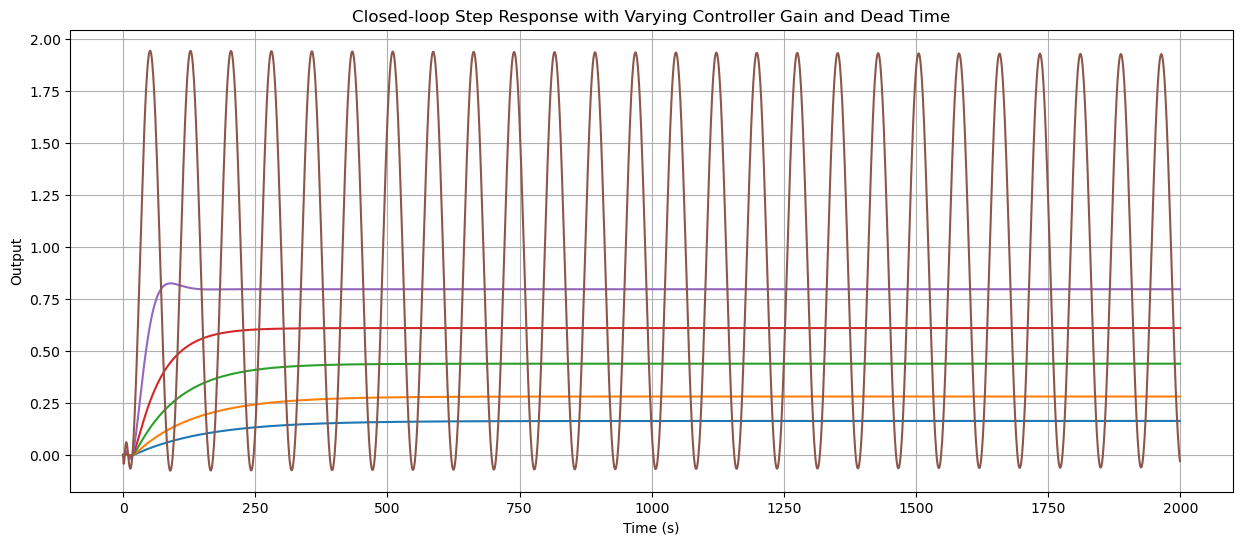

In [383]:
# Define new transfer function with dead time using Pade approximation
num, den = cs.pade(theta, 3)  # Pade approximation of dead time
Gs_dead_time = cs.TransferFunction(num, den) * G # System with dead time

# System configuration done with closed-loop control and proportional pure action
plt.figure(figsize=(15, 6))

for i in [0.25, 0.5, 1, 2, 5, 17.752]:  # Different controller gains - by varying the last value for the brown trace, we define 17.752 as a Ke
    Controller = cs.TransferFunction([i], [1])  # Proportional controller with varying gain
    Closed_Loop = cs.feedback(Controller * Gs_dead_time, 1)  # Closed-loop transfer function

# Step response of closed-loop system
    t_cl, y_cl = cs.step_response(Closed_Loop, t)  # Step response of closed-loop system
    plt.plot(t_cl, y_cl, label=f'Closed-loop Response with Dead Time (Gain={i})')

plt.title('Closed-loop Step Response with Varying Controller Gain and Dead Time')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.grid()
plt.show()




Acorde a la variación de nuestro valores podemos decir que:

$$K_u \approx 17.752$$

$$P_u \approx 77.2s $$

# Diseño del Controlador - Planeación

Con nuestros parametros previamente calculados de $K_u$ y $P_u$, definimos nuestros parametros para el PID con Ziegler Nichols.

$$K_p \approx 10.6512$$

$$T_i \approx 38.6s$$

$$T_d \approx 9.65s$$